In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
alpha = 1.

def gamma_k(_kx, _ky):
    return (np.cos(_kx) + np.cos(_ky))/2

def a_k(t, n, delta = 1., lamb = 0.):
    return 2 * (delta + t - alpha * 2 * n * (t/2 + lamb * delta))

def b_k(t, n, I, _kx, _ky, delta = 1., lamb = 0.):
    return 2 * (1 - 2 * n + I + alpha * t * (t/2 + lamb * delta) ) * gamma_k(_kx, _ky)

def get_alpha(t, n, I, _kx, _ky, delta = 1., lamb = 0.):
    ak = a_k(t, n, delta, lamb)
    bk = b_k(t, n, I, _kx, _ky, delta, lamb)

    wk = np.sqrt(np.abs(ak**2 - bk**2))
    
    alpha_plus = np.sqrt(1/2 * (ak/wk + 1))
    alpha_minus = np.sign(bk) * np.sqrt(1/2 * np.abs(ak/wk - 1))

    return alpha_plus, alpha_minus

def t(a_plus, a_minus, gamma_k, N):
    return 2/N * np.sum(a_plus * a_minus * gamma_k)

def n(a_plus, a_minus, N):
    return 1/N * np.sum(a_minus**2)

def I(a_plus_k, a_minus_k, a_plus_q, a_minus_q, kx, ky, qx, qy, N):
    return 1/(2*N**2) * np.sum((a_plus_k * a_minus_k * a_plus_q * a_minus_q) * 2 * gamma_k(kx + qx, ky + qy)
                         + (a_minus_k**2 * a_plus_q**2) * 2 * gamma_k(kx - qx, ky - qy))

In [3]:
def SC_MF(delta = 1., lamb = 0., leapfrog : bool = False, k_bins = 50, n_steps = 10, disable_tqdm = False):
    # strating parameters
    n_old = np.random.uniform(0.4, .6)
    t_old = np.random.uniform(0.45, .65)
    I_old = np.random.uniform(0.4, .7)
    n_old = 0.5
    t_old = 0.56
    I_old = 0.1
    #print(n_old, t_old, I_old)

    N = k_bins**2
    k = np.linspace(-np.pi, np.pi, k_bins, endpoint = False)

    px, py = np.meshgrid(k, k, indexing = 'ij')
    kx, ky, qx, qy = np.meshgrid(k, k, k, k, indexing = 'ij')

    t_array = []
    n_array = []
    I_array = []

    for _ in tqdm(range(n_steps), disable = disable_tqdm):
        # get general parameters
        apk, amk = get_alpha(t_old, n_old, I_old, px, py, delta, lamb)
        gammak = gamma_k(px, py)

        # get new t
        t_new = t(apk, amk, gammak, N)

        # if leapfrog -> update t and delta_k
        if leapfrog:
            t_old = t_new
            apk, amk = get_alpha(t_old, n_old, I_old, px, py, delta, lamb)

        # get new n
        n_new = n(apk, amk, N)

        # if leapfrog -> update n
        if leapfrog:
            n_old = n_new

        # to satisfy both methods, it is better to calculate q here
        apk, amk = get_alpha(t_old, n_old, I_old, kx, ky, delta, lamb)
        apq, amq = get_alpha(t_old, n_old, I_old, qx, qy, delta, lamb)

        # get new I
        I_new = I(apk, amk, apq, amq, kx, ky, qx, qy, N)

        t_old = t_new
        n_old = n_new
        I_old = I_new

        t_array.append(t_old)
        n_array.append(n_old)
        I_array.append(I_old)
        
    return np.array(t_array), np.array(n_array), np.array(I_array), range(n_steps)

In [4]:
def disp(n, t, I, delta = 1., l = 0.):

    ak = a_k(t, n, delta, l)
    bk = b_k(t, n, I, 0, 0, delta, l)

    #print(f'Ak = {round(ak, 5)}, Bk = {round(bk, 5)}')

    if bk**2 > ak**2:
        print('IMAGINARY')
        print(f'Ak = {round(ak, 5)}, Bk = {round(bk, 5)}')

    gap_g = np.sqrt(np.abs(ak**2 - bk**2))
    gap_x = np.sqrt(np.abs(ak**2))

    print(f'Gap at G point: {round(gap_g, 3)}')
    
    print(f'Gap at X point: {round(gap_x, 3)}')

In [5]:
def get_mf(delta = 1., lamb = 0., k_bins = 50, froggie = True, plot_changes : bool = False):
    ts, ns, Is, steps = SC_MF(delta, lamb, leapfrog=froggie, k_bins=k_bins, n_steps = 20, disable_tqdm = False)
    fin_t = ts[-1]
    fin_n = ns[-1]
    fin_I = Is[-1]

    print(f'Final t = {round(fin_t, 5)}')
    print(f'Final n = {round(fin_n, 5)}')
    print(f'Final I = {round(fin_I, 5)}')

    if plot_changes:
        plt.scatter(steps[1:], abs(ts[1:] - np.roll(ts[:-1], 1)), label = 't')
        plt.scatter(steps[1:], abs(ns[1:] - np.roll(ns[:-1], 1)), label = 'n')
        plt.scatter(steps[1:], abs(Is[1:] - np.roll(Is[:-1], 1)), label = 'I')
        plt.yscale('log')
        plt.show()

    disp(fin_n, fin_t, fin_I, delta, lamb)

In [6]:
def get_akbk(delta = 1., lamb = 0., k_bins = 50, froggie = True):
    ts, ns, Is, steps = SC_MF(delta, lamb, leapfrog=froggie, k_bins=k_bins, n_steps = 20, disable_tqdm = True)
    fin_t = ts[-1]
    fin_n = ns[-1]
    fin_I = Is[-1]
    ak = a_k(fin_t, fin_n, delta, lamb)
    bk = b_k(fin_t, fin_n, fin_I, 0, 0, delta, lamb)
    return ak, bk


In [8]:
get_mf(1., 0., k_bins = 50)
#get_mf(1., 1., k_bins = 50)
#print()
get_mf(1.44, 0., k_bins = 50)
#get_mf(1.44, 1., k_bins = 50)
#print()
get_mf(2., 0., k_bins = 50)
#get_mf(2., 1., k_bins = 50)

  0%|          | 0/20 [00:00<?, ?it/s]


TypeError: 'float' object is not callable

In [ ]:
g_points = []
x_points = []

d_range = np.arange(1., 5.01, .025)

for d in tqdm(d_range):
    ak, bk = get_akbk(d, 1.)
    g_points.append(ak**2 - bk**2)
    x_points.append(ak)

100%|██████████| 161/161 [13:55<00:00,  5.19s/it]


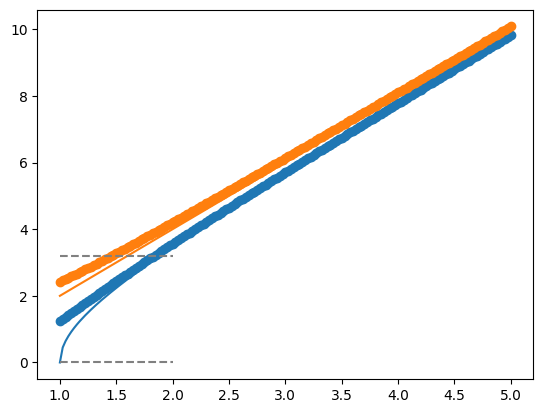

In [ ]:
plt.scatter(d_range, np.sqrt(g_points), label = r'$\Gamma$')
plt.scatter(d_range, x_points,label =  r'$X$')
plt.plot(d_range, 2*np.sqrt(d_range**2 - 1), label = r'LSW at $\Gamma$')
plt.plot(d_range, 2*np.sqrt(d_range**2), label = r'LSW at $X$')
plt.hlines([0., 3.19], 1, 2, colors = 'gray', ls = '--')
plt.show()

IMAGINARY
Ak = 1.84, Bk = 1.8968
Gap at G point: 0.4607
Gap at X point: 1.84


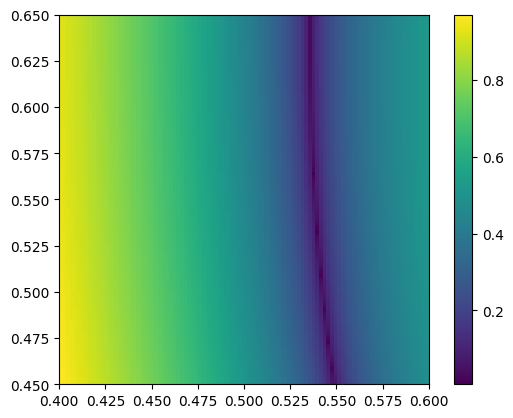

In [ ]:
n_min = .4
n_max = .6

t_min = .45
t_max = .65

ns = np.linspace(n_min, n_max, 101)
ts = np.linspace(t_min, t_max, 101)

ns, ts = np.meshgrid(ns, ts)

I = 0.59

ak = a_k(ts, ns, 1., 1.)
bk = b_k(ts, ns, I, 0., 0., 1., 1.)

disp(.5, .56, .59, 1., 1.)

plt.imshow(np.sqrt(np.abs(ak**2 - bk**2)), extent=(n_min, n_max, t_min, t_max))
plt.colorbar()
plt.show()